# Agriculture Output vs Underemployment Analysis

This notebook provides an in-depth analysis of the relationship between the **Agricultural Production Index** and the **Underemployment Rate** in Sri Lanka.
It mirrors the comprehensive exploratory and statistical depth seen in previous macro-labour combinations, explicitly tailored to the project proposal's methodology.

## 1. Data Loading & Initial Exploration

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('default')

# Load combined master dataset
df = pd.read_csv('../DataLoader/master_dataset.csv')

# Clean column names
df.columns = df.columns.str.strip()

# Select relevant features based on the proposal
df = df[['Year', 'Underemployment_Rate', 'AgriProdIdx_Agriculture']].copy()
df.rename(columns={'AgriProdIdx_Agriculture': 'Agriculture_Output_Index'}, inplace=True)

# Convert to numeric
df['Underemployment_Rate'] = pd.to_numeric(df['Underemployment_Rate'], errors='coerce')
df['Agriculture_Output_Index'] = pd.to_numeric(df['Agriculture_Output_Index'], errors='coerce')

# Create Datetime Index
# Note: The dataset contains yearly data for this analysis
df = df.dropna(subset=['Year'])
df['Year'] = pd.to_datetime(df['Year'].astype(str).str.split('.').str[0], format='%Y')
df.set_index('Year', inplace=True)

print("Data Info:")
print(df.info())
df.head()

Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10 entries, 2015-01-01 to 2024-01-01
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Underemployment_Rate      10 non-null     float64
 1   Agriculture_Output_Index  10 non-null     float64
dtypes: float64(2)
memory usage: 240.0 bytes
None


,Underemployment_Rate,Agriculture_Output_Index
Year,,
2015-01-01,2.7,104.46
2016-01-01,2.4,98.63
2017-01-01,2.8,89.14
2018-01-01,2.6,96.74
2019-01-01,2.7,98.47


## 2. Missing Values Analysis & Imputation

In [7]:
print("Missing values in Underemployment_Rate:", df['Underemployment_Rate'].isnull().sum())
print("Missing values in Agriculture_Output_Index:", df['Agriculture_Output_Index'].isnull().sum())

# Applying Linear Interpolation (Best practice for macroeconomic time series as defined in methodology)
df_clean = df.interpolate(method='linear').bfill().ffill()

print("\nPost-imputation completeness verified.")
print(df_clean.isnull().sum())

Missing values in Underemployment_Rate: 0
Missing values in Agriculture_Output_Index: 0

Post-imputation completeness verified.
Underemployment_Rate        0
Agriculture_Output_Index    0
dtype: int64


## 3. Comprehensive Correlation Analysis

In [8]:
u_vals = df_clean['Underemployment_Rate'].values
f_vals = df_clean['Agriculture_Output_Index'].values

pearson_r, pearson_p = stats.pearsonr(f_vals, u_vals)
spearman_r, spearman_p = stats.spearmanr(f_vals, u_vals)

print("=" * 60)
print("CORRELATION STATISTICS")
print("=" * 60)
print(f"Pearson (Linear):       r = {pearson_r:.4f}  | p-value = {pearson_p:.6f}")
print(f"Spearman (Monotonic):   Rho = {spearman_r:.4f} | p-value = {spearman_p:.6f}")
print("=" * 60)


CORRELATION STATISTICS
Pearson (Linear):       r = -0.1596  | p-value = 0.659693
Spearman (Monotonic):   Rho = -0.1043 | p-value = 0.774305


## 4. Extensive Visualization (Structural Patterns)

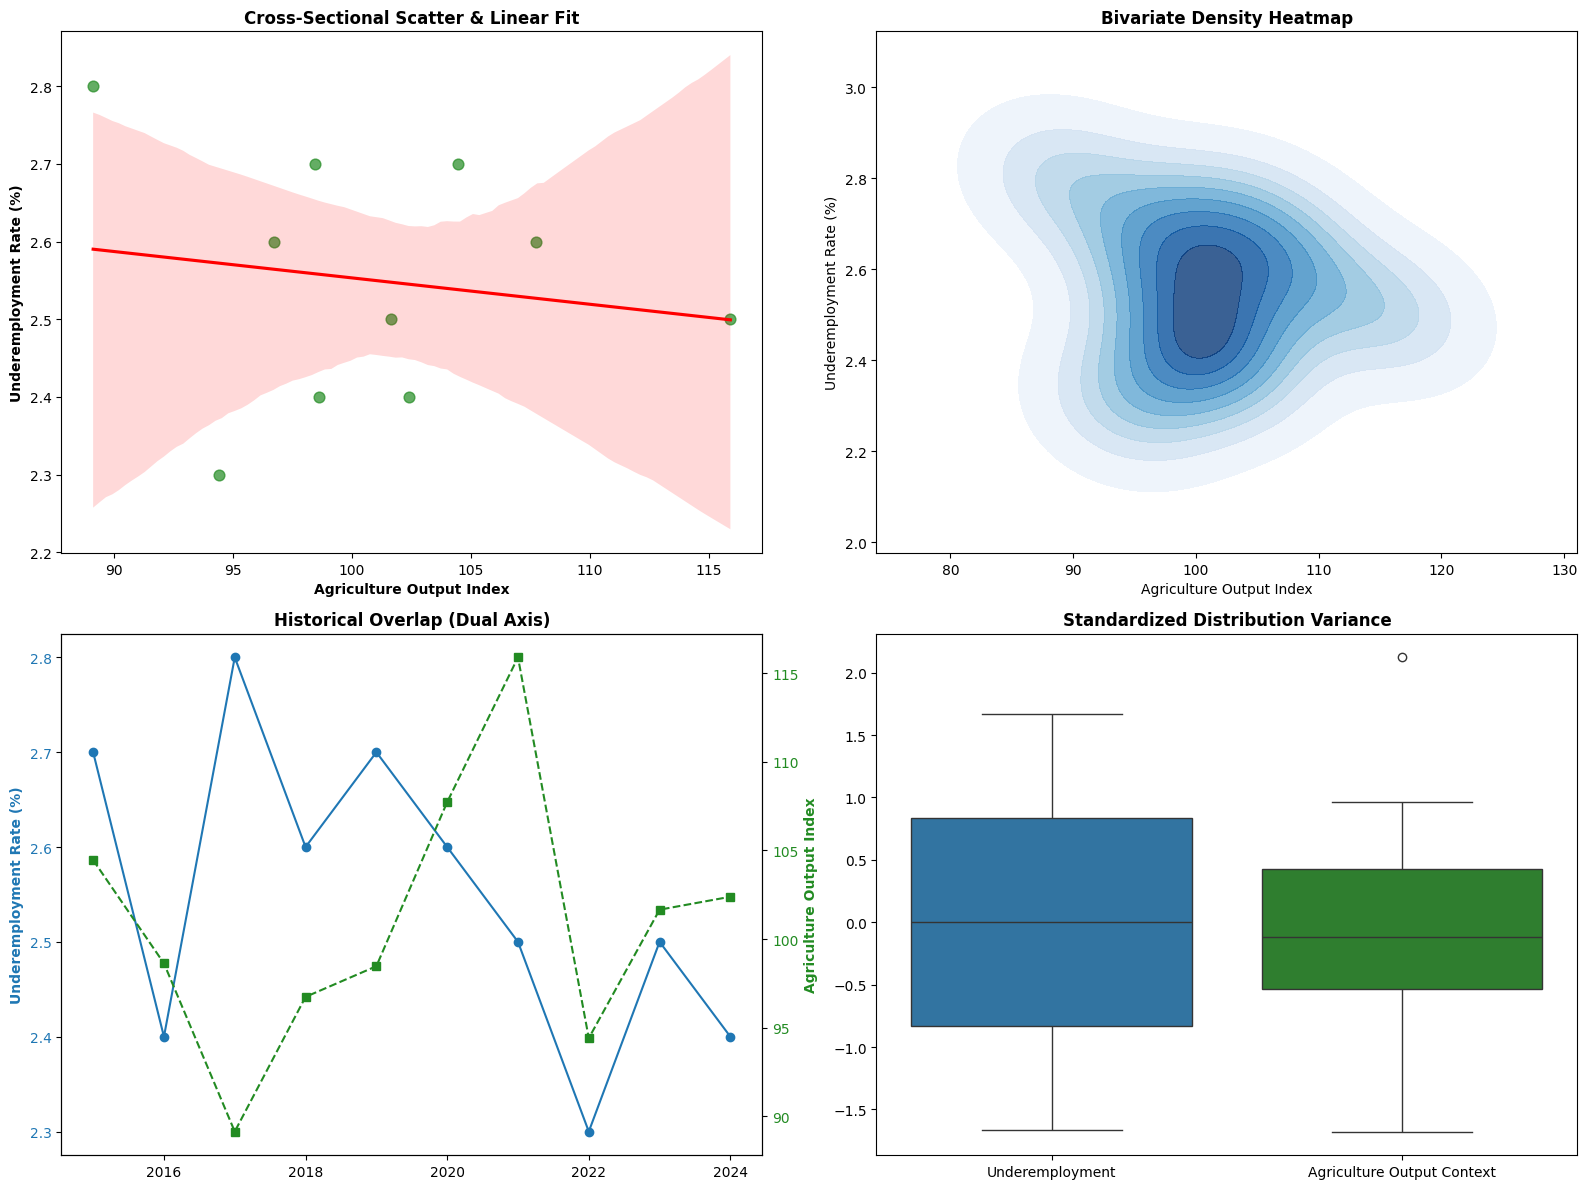

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Scatter with Regression Line
sns.regplot(x=f_vals, y=u_vals, ax=axes[0, 0], scatter_kws={'alpha': 0.7, 's': 60}, line_kws={'color': 'red'}, color='forestgreen')
axes[0, 0].set_xlabel('Agriculture Output Index', fontweight='bold')
axes[0, 0].set_ylabel('Underemployment Rate (%)', fontweight='bold')
axes[0, 0].set_title('Cross-Sectional Scatter & Linear Fit', fontweight='bold')

# 2. KDE Density Plot (Bivariate)
sns.kdeplot(x=f_vals, y=u_vals, ax=axes[0, 1], cmap='Blues', fill=True, alpha=0.8)
axes[0, 1].set_xlabel('Agriculture Output Index')
axes[0, 1].set_ylabel('Underemployment Rate (%)')
axes[0, 1].set_title('Bivariate Density Heatmap', fontweight='bold')

# 3. Time Series Dynamics
ax_time = axes[1, 0]
ax_time.plot(df_clean.index.year, df_clean['Underemployment_Rate'], color='tab:blue', marker='o', label='Underemployment')
ax_time.set_ylabel('Underemployment Rate (%)', color='tab:blue', fontweight='bold')
ax_time.tick_params(axis='y', labelcolor='tab:blue')
ax_twin = ax_time.twinx()
ax_twin.plot(df_clean.index.year, df_clean['Agriculture_Output_Index'], color='forestgreen', marker='s', linestyle='--', label='Agriculture Output Index')
ax_twin.set_ylabel('Agriculture Output Index', color='forestgreen', fontweight='bold')
ax_twin.tick_params(axis='y', labelcolor='forestgreen')
ax_time.set_title('Historical Overlap (Dual Axis)', fontweight='bold')

# 4. Boxplots for Data Distribution
bp_data = pd.DataFrame({'Underemployment': (u_vals - u_vals.mean()) / u_vals.std(), 
                      'Agriculture Output Context': (f_vals - f_vals.mean()) / f_vals.std()})
sns.boxplot(data=bp_data, ax=axes[1, 1], palette=['tab:blue', 'forestgreen'])
axes[1, 1].set_title('Standardized Distribution Variance', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Advanced Models: Linear Regression & Residuals

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X = f_vals.reshape(-1, 1)
y = u_vals

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
residuals = y - y_pred

print("REGRESSION DIAGNOSTICS")
print(f"R-squared Score: {r2_score(y, y_pred):.4f}")
print(f"RMSE:            {np.sqrt(mean_squared_error(y, y_pred)):.4f}")
print(f"Coefficient:     {model.coef_[0]:.4f}")
print(f"Intercept:       {model.intercept_:.4f}")


REGRESSION DIAGNOSTICS
R-squared Score: 0.0255
RMSE:            0.1481
Coefficient:     -0.0034
Intercept:       2.8931


## 6. Lagged Analysis (Time Delays in Macro Effects)

In [11]:
print("LAG ANALYSIS: Macro-factors often take time to impact underemployment.")
print("=" * 70)

# Using 1 to 4 periods (as defined in project proposal 'engineered lag features t-1, t-2, t-4')
lags_to_test = [0, 1, 2, 3, 4]

for lag in lags_to_test:
    shifted_feature = df_clean['Agriculture_Output_Index'].shift(lag)
    corr = df_clean['Underemployment_Rate'].corr(shifted_feature)
    print(f"Lag {lag} Years: correlation = {corr:.4f}")

print("\nThis identifies how many observation periods it takes for agricultural changes to penetrate the labour market.")


LAG ANALYSIS: Macro-factors often take time to impact underemployment.
Lag 0 Years: correlation = -0.1596
Lag 1 Years: correlation = -0.6373
Lag 2 Years: correlation = -0.2716
Lag 3 Years: correlation = -0.3379
Lag 4 Years: correlation = 0.1388

This identifies how many observation periods it takes for agricultural changes to penetrate the labour market.
